In [1]:
import sys, os
print(os.getcwd())
print(sys.path[0])

c:\Users\trakw\_workspace\micrograd-from-scratch
C:\Users\trakw\miniforge3\python313.zip


In [32]:
%load_ext autoreload
%autoreload 2

from micrograd.engine import Value
from micrograd.topo import topo
from micrograd.viz import plot_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


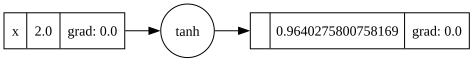

In [20]:
x = Value(2.0, "x")
y = x.tanh()
plot_graph(y)     # แก้ engine.py แล้วเซฟ รันเซลล์ใหม่ได้เลย ไม่ต้อง restart

In [21]:
y._backward()

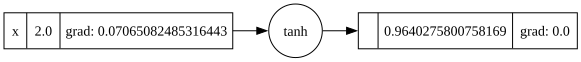

In [22]:
plot_graph(y)

In [14]:
y = Value(0.0).tanh()
print(y._backward)
# → <function Value.__init__.<locals>.<lambda> at 0x...>

a = Value(1.0) * Value(2.0)
print(a._backward)
# → <function Value.__mul__.<locals>._backward at 0x...>


<function __autoreload_class__.tanh.<locals>._backward at 0x00000206E5BBA8E0>
<function Value.__mul__.<locals>._backward at 0x00000206E5BBACA0>


In [17]:
print(y._backward.__qualname__)
print(y._backward.__code__.co_freevars)

__autoreload_class__.tanh.<locals>._backward
('self', 't')


In [25]:
l = [1,2,3]
print(l)
print(*l)

[1, 2, 3]
1 2 3


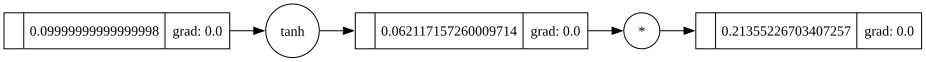

In [33]:
x = Value(0.5)
y = x.tanh()
z = y * y
plot_graph(z)

In [28]:
z.backward()

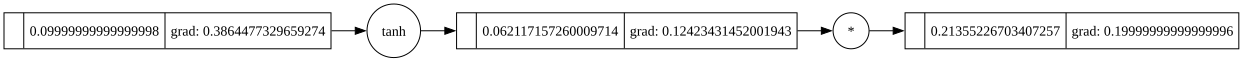

In [30]:
plot_graph(z)

# NN

In [235]:
%load_ext autoreload
%autoreload 2


from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP
from micrograd.topo import topo
from micrograd.viz import plot_graph
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
n1 = Neuron(3)
print(n1)

Neuron(ws = [Value(data = -0.416, label = ), Value(data = -0.8258, label = ), Value(data = 0.284, label = )], b = Value(data = 0.3972, label = ))


In [27]:
print(MLP(3, [4, 1]))

MLP(nin = 3, neurons_per_layer = [4, 1])


# Training Loop

## Manual

In [106]:
net = MLP(3, [4, 4, 1])
x_gt = [1, 2, 3]
y_gt = [0.5]

In [ ]:
net.parameters()

In [ ]:
# forward pass & loss
y = net(x_gt)
loss = sum((a-b)**2 for a,b in zip(y, y_gt))/len(y_gt)

In [ ]:
plot_graph(loss)

In [213]:
# backpass pass for gradients
loss.backward()

In [214]:
# update parameters using gradients
lr = 0.1
for p in net.parameters():
    p.data -= lr * p.grad

In [215]:
# forward pass again to get new loss
for p in net.parameters():
    p.grad = 0
y = net(x_gt)
loss = sum((a-b)**2 for a,b in zip(y, y_gt))/len(y_gt)
print(f"y = {y}")
print(f"loss = {loss}")

y = [Value(data = 0.5, label = )]
loss = Value(data = 5.748e-16, label = )


## Loop

In [ ]:
import random
random.seed(42)

net = MLP(3, [4, 4, 1])
x_gts = [[1, 2, 3], [0, 2, 3], [-1, 0, 1], [-2, -3, 1]]
y_gts = [0.5, 1, -1, -0.5]

In [270]:
steps = 100
lr = 0.05
loss_history = []
ys_history = []

for step in range(steps):
    # forward pass & loss
    ys = []
    for x_gt in x_gts:
        ys.append(net(x_gt)[0])
    ys_history.append(ys)
    loss = sum((a - b) ** 2 for a, b in zip(ys, y_gts, strict=True)) / len(ys)
    loss_history.append(loss)
    # backpass pass for gradients
    loss.backward()
    # update parameters using gradients
    net.update(lr)
    # set gradients to zero
    net.zero_grad()

Text(0.5, 1.0, 'Training trajectory per variable')

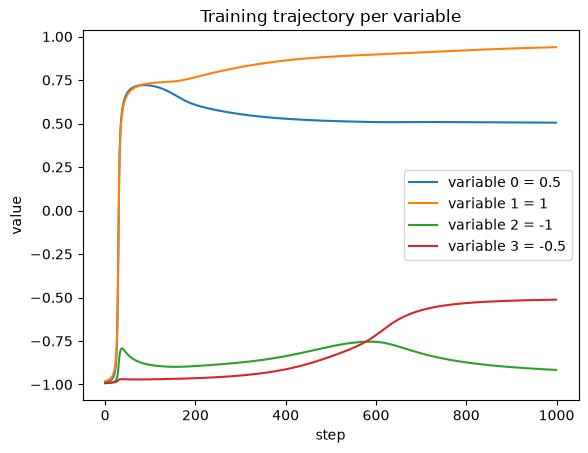

In [271]:
for i in range(4):
    plt.plot([ys[i].data for ys in ys_history], label=f"variable {i} = {y_gts[i]}")

plt.legend()
plt.xlabel("step")
plt.ylabel("value")
plt.title("Training trajectory per variable")

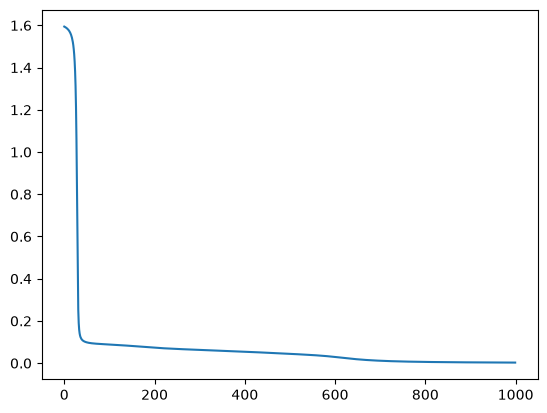

In [272]:
plt.plot([loss.data for loss in loss_history])

## Understading gradient again

In [ ]:
a = Value(3); a.label = "a"
b = Value(-2); b.label = "b"
c = Value(10); c.label = "c"
d = a*b+c; d.label = "d"

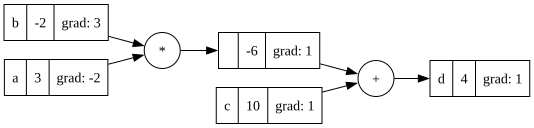

In [219]:
plot_graph(d)

In [222]:
a = Value(3-(-2)); a.label = "a"
b = Value(-2); b.label = "b"
c = Value(10); c.label = "c"
d2 = a*b+c; d.label = "d"
print(d2)

Value(data = 0, label = )


In [218]:
d.backward()

# Python

## Decorator

```
@foo
def bar():
    ...
```

=

```
def bar():
    ...
bar = foo(bar)
```

### Ex1

In [39]:
def printfooafter(f):
    def g():
        f()
        print("foo")
    return g

In [42]:
def bar():
    print("bar")

bar()

bar


In [43]:
@printfooafter
def bar():
    print("bar")
     
bar()

bar
foo


### Ex2

In [46]:
def greet():
    return "hi"
    
f = greet
f()

'hi'

In [47]:
def shout(fn):
    def wrapper():
        return fn().upper() + "!"
    return wrapper

loud = shout(greet)
loud()

'HI!'

In [48]:
@shout
def greet():
    return "hi"

greet()

'HI!'

### Ex3

In [49]:
def cases(*values):
    def attach(fn):
        fn.cases = values
        return fn
    return attach

@cases(1, 2, 3)
def double(x):
    return x*2

double(5)

10

In [65]:
double.cases

(1, 2, 3)

In [64]:
cases

<function __main__.cases(*values)>

In [63]:
pytest.mark.parametrize

MarkDecorator(mark=Mark(name='parametrize', args=(), kwargs={}))

In [50]:
for c in double.cases:
    print(f"double[{c}] -> {double(c)}")

double[1] -> 2
double[2] -> 4
double[3] -> 6


### Ex4

In [51]:
import pytest

CASES = [
    pytest.param(2, 3, 5, id="2+3"),
    pytest.param(10, 1, 11, id="10+1"),
]

@pytest.mark.parametrize("a, b, expected", CASES)
def test_adds(a, b, expected):
    assert a + b == expected


In [52]:
@pytest.mark.parametrize('x', [1, 2, 3])
def demo(x):
    return x

In [62]:
demo(5)
print(demo.pytestmark)

[Mark(name='parametrize', args=('x', [1, 2, 3]), kwargs={})]


In [60]:
sorted(demo.__dict__)

['pytestmark']

In [58]:
def plain(): pass
plain.anything_i_want = {'a': 1}     # ใส่อะไรก็ได้
plain.anything_i_want

{'a': 1}

In [61]:
sorted(plain.__dict__)

['anything_i_want']

### Ex5

In [67]:
a = [1,2,3]
*a

SyntaxError: can't use starred expression here (1087030344.py, line 2)

In [ ]:
import pytest

CASES = [
    pytest.param(2, 3, 5, id="2+3"),
    pytest.param(10, 1, 11, id="10+1"),
]

@pytest.mark.parametrize("a, b, expected", CASES)
def test_adds(a, b, expected):
    assert a + b == expected


In [83]:
def myparametrize(myvar, mycase):
    def attach(fn):
        fn.myvar = myvar
        fn.mycase = mycase
        return fn
    return attach

mycase = [
    (1, 2, 3),
    (4, 5, 9)
]

@myparametrize("a, b, c", mycase)
def mytest(a, b, c):
    # print(f"a = {a}")
    # print(f"b = {b}")
    # print(f"c = {c}")
    assert a + b == c
    print(f"{a}+{b}={c}")
    
myvarliststring = [p.strip() for p in mytest.myvar.split(",")]

for c in mytest.mycase:
    mytest(*c)

1+2=3
4+5=9


## Type Test

In [85]:
a = Value(1)
type(a) == Value

True

In [94]:
print(type(1) is int or float)
print(type(1.0) is (int or float))
print(type(Value(1.0)) is (int or float))

True
False
False


In [91]:
type(1.0)

float

In [97]:
assert isinstance(1.0, (int, float))
assert isinstance(Value(1.0), (int, float))

AssertionError: 

## `__call__`

In [1]:
class Greeter:
    def __init__(self, name):     # รันครั้งเดียว ตอนสร้าง object
        self.name = name

    def __call__(self, mood):     # รันทุกครั้งที่ใส่วงเล็บ
        return f"{mood}, {self.name}!"

In [2]:
g = Greeter("world")     #→ [__init__] ทำงาน
g("hello")               #→ "hello, world!"
g("goodbye")             #→ "goodbye, world!"    object เดิม เรียกใหม่ได้เรื่อยๆ
callable(g)              #→ True

True

In [3]:
a = [1, 2, 3]
[*a, 4]

[1, 2, 3, 4]

In [5]:
a = [1, 2, 3]
b = ["x", "y", "z"]
list(zip(a, b))

[(1, 'x'), (2, 'y'), (3, 'z')]

In [8]:
a = [1, 2, 3]
b = [4, 5, 6]
sum(a*b for a, b in zip(a, b))

32

In [10]:
a = [1, 2, 3]
b = [4, 5, 6]
c = [7, 8, 9]
abc = [a, b, c]

In [ ]:
# list((*l) for l in abc)

[x for l in abc for x in l]
# -> [1, 2, 3, 4, 5, 6, 7, 8, 9]

SyntaxError: iterable unpacking cannot be used in comprehension (691615034.py, line 1)

## Unpacking in function input

In [14]:
def f1(*xs):
    print(xs)

f1(1, 2, 3)

(1, 2, 3)


In [ ]:
def f1(**kwargs):
    print(kwargs)

f1(a=1, b=2)

{'a': 1, 'b': 2}


## Zip

In [20]:
a = [1,2,3]
list(zip([0, *a], a))

[(0, 1), (1, 2), (2, 3)]